# Pytorch y representación de datos 

## Objetivo

- Abordar conceptos fundamentales del framework `pytorch`
- Mostrar como la representación adecuada de datos es crucial en la creación de modelos de *ML*

## Representación de datos

- Elegir una buena representación de datos es crucial en la creación de modelas de *ML*
- Los *features* o *rasgos* definen vectores en espacios $d$-dimensionales con los que trabajará la máquina de aprendizaje. Podemos ver el impacto de los datos en el siguiente ejemplo.

### Representación cartesiana

- Generaremos un conjunto de datos para una clasificación binaria
- Estos datos perteneceran a una 1-esfera que, además, contenga un factor de ruido
- Visualizemos en coordenadas cartesianas

In [2]:
from rich import print as rprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Generación de datos con ruido blanco
t = np.linspace(0, 2 * np.pi, 100)
# Desviacion estandar
std = 0.9
# Par de radios
r1, r2 = 10, 5

In [4]:
x1, y1 = (
    r1 * np.cos(t) + np.random.normal(0, std, 100),
    r1 * np.sin(t) + np.random.normal(0, std, 100),
)
x2, y2 = (
    r2 * np.cos(t) + np.random.normal(0, std, 100),
    r2 * np.sin(t) + np.random.normal(0, std, 100),
)

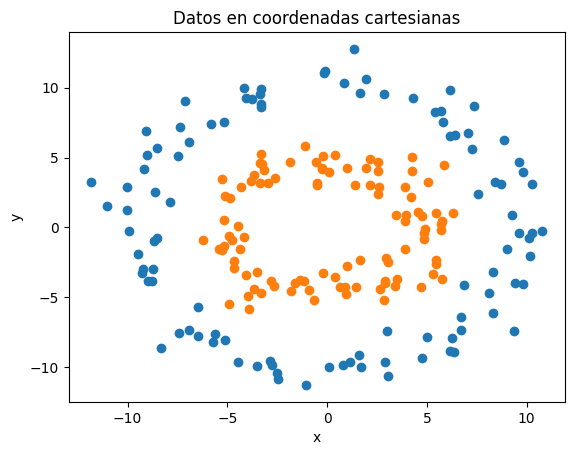

In [5]:
# Visualización
plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.title("Datos en coordenadas cartesianas")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

- En las coordenadas cartesianas los datos son conjuntos no convexos, por lo que no existe un separador lineal que pueda clasificar correctamente los datos.
- Si tomamos las coordenadas polares, podemos observar que la disposición de los datos en el espacio de rasgos cambia. 

### Representación polares

- Recordemos que obtenemos las coordenadas polares como $x_{polar} = \begin{pmatrix} \rho & \theta \end{pmatrix}$, donde la longitud está determinada como:

$$\rho = \sqrt{x^2 + y^2}$$

Y el ángulo está dado por:

$$\theta = \arctan(\frac{y}{x})$$

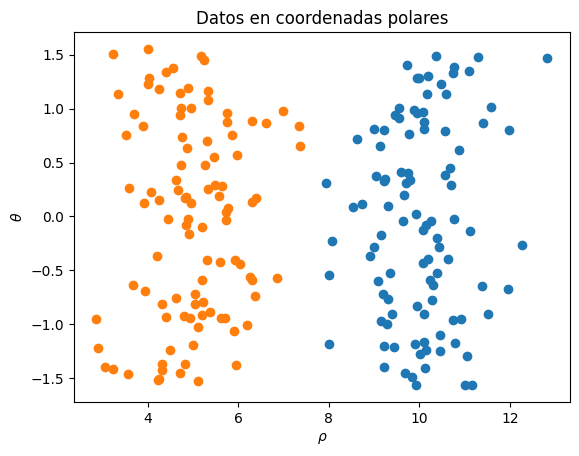

In [6]:
# Funciones para transformar a coordenadas polares
polar_rho = lambda x, y: np.sqrt(x**2 + y**2)
polar_theta = lambda x, y: np.arctan(y / x)

# Coordenadas polares de los datos
rho1, theta1 = polar_rho(x1, y1), polar_theta(x1, y1)
rho2, theta2 = polar_rho(x2, y2), polar_theta(x2, y2)

# Visualización
plt.scatter(rho1, theta1)
plt.scatter(rho2, theta2)
plt.title("Datos en coordenadas polares")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$\theta$")
plt.show()

En el *feature space* de las coordenadas polares los datos sí son línealmente separables, por lo que está forma de codificar los rasgos de los datos parece una mejor opción.

## Codificación de rasgos

- Los modelos de *ML* son alimentados con **feature vectors**
- Estos son vectores con *features* que representen efectivamente nuestro problema a resolver

<center><img src="https://developers.google.com/static/machine-learning/crash-course/images/dataset_to_feature_vector_to_model_scaled.svg"></center>

> Tomado de Google developers - Machine Learning

La **representación de los datos** consiste en pasar de los objetos que se quieren procesar con un modelo de *ML* a vectores aleatorios. 

Las *features* o **rasgos** son variables aleatorias que representan características relevantes de los objetos con los que estamos trabajando. 

Estos rasgos se representan en un vector $d$-dimensional:

$$x^T = \begin{pmatrix} X_1 = x_1 & X_2 = x_2 \cdots & X_d = x_d \end{pmatrix}$$

Cada rasgo $X_i=x_i$ es el valor que toma una variable aleatoria. Se asume que $X_i \perp X_j$ cuando $i \neq j$. Por ejemplo, una variable puede responder al tamaño del objeto, por lo que las features serán números que representen esto. O bien pueden ser variables categóricas, como color, si pertenece o no a un grupo, etc.

In [7]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

rprint("\n".join(data.feature_names))

mean radius
mean texture
mean perimeter
mean area
mean smoothness
mean compactness
mean concavity
mean concave points
mean symmetry
mean fractal dimension
radius error
texture error
perimeter error
area error
smoothness error
compactness error
concavity error
concave points error
symmetry error
fractal dimension error
worst radius
worst texture
worst perimeter
worst area
worst smoothness
worst compactness
worst concavity
worst concave points
worst symmetry
worst fractal dimension

In [10]:
data.frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


- Es importante códificar adecuadamente los datos para que los modelos puedan aprender adecuadamente
    - A esta actividad de le suele llamar [*feature engineering*](developers.google.com/machine-learning/glossary#feature-engineering)
    - Definición de **feature enginering:** ?
- En contraste, en modelos de *Deep Learning, DL*, la codificación optima es aprendida por la red neuronal

## Pytorch intro

### ¿Qué es pytorch?

[PyTorch](https://pytorch.org/) es un framework para hacer *Deep Learning*, y es uno de los más populares junto con [Tensorflow](https://www.tensorflow.org/?hl=es). Su instalación puede realizarse de muchas formas distintas ya sea si querramos habilitar soporte para aceleradores (como una GPU) o si solo queremos soporte para CPU. Más información sobre su instalación en la [documentación](https://pytorch.org/get-started/locally/)

La forma más sencilla de comenzar a utilizar `PyTorch` probablemente sería en un [Notebook de Colab](https://colab.research.google.com/) donde ya está configurado el paquete para utilizar los aceleradores disponibles (dependiendo del [entorno seleccionado](https://research.google.com/colaboratory/faq.html#gpu-availability))

#### Local first (?)

Recomiendo ampliamente utilizar `uv` y seguir [su documentación](https://docs.astral.sh/uv/guides/integration/pytorch/) para gestionar proyectos que utilicen `pytorch`

In [ ]:
import torch

### Tensores

Los **Tensores** son el bloque de construcción más básico de `PyTorch`. Cada tensor puede verse como una matríz multidimensional que representará datos en nuestros *pipelines* de entrenamiendo. Por ejemplo, una imágen de 256x256 puede representarse como un tensor de `3x256x256` donde la primera dimensión representará el color.

In [ ]:
data = torch.tensor(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ]
)
rprint(data)

In [ ]:
data.shape

`PyTorch` permite la inter-conversión con arreglos de `numpy`

In [ ]:
array = np.array([[1, 0, 5]])
data = torch.tensor(array)
rprint("Tensor:", data)

new_array = data.numpy()
rprint("np array:", new_array)

Los tensores nos permite realizar *operaciones vectorizadas*: operaciones que se realizan en paralelo sobre alguna dimensión particular del tensor.

In [ ]:
data = torch.arange(1, 36, dtype=torch.float32).reshape(5, 7)
rprint("[bold blue]Data")
rprint(data)

rprint("Sumando sobre las filas ([green]dim=1)[/]: ")
rprint(data.sum(dim=1)) # (5,)

rprint("Sumando sobre las columnas ([green]dim=0)[/]: ")
rprint(data.sum(dim=0)) # (7,)

rprint("Promedio sobre las filas ([green]dim=1)[/]: ")
rprint(data.mean(dim=1)) # (5,)

rprint("Calculando stdev sobre las filas")
rprint(data.std(dim=1))

In [ ]:
data = torch.arange(1, 7, dtype=torch.float32).reshape(1, 2, 3)
rprint(data)
rprint(data.sum(dim=0).sum(dim=0))
rprint(data.sum(dim=0).sum(dim=0).shape)

In [ ]:
rprint(data.sum())

### Indexado

In [ ]:
X = torch.tensor(
    [
        [[1, 2], [3, 4]],
        [[5, 6], [7, 8]],
        [[9, 10], [11, 12]]
    ]
)
rprint(X)

In [ ]:
rprint(X.shape)

In [ ]:
# Equivale a X[0, :]
rprint(X[0])

In [ ]:
# Obtenemos de todas las columnas el elemento 1
rprint(X[:, 1])

In [ ]:
# Obtenemos de todas las columnas
# elemento 0 y de esos tensores el elemento 0
rprint(X[:, 0, 0])

In [ ]:
rprint(X[:,:,:])

In [ ]:
# Accediendo a los elementos 0 y 1, dos veces
i = torch.tensor([0, 0, 1, 1])
X[i]

In [ ]:
# Accediendo al elemento 0 del 1 y 2 elemento
i = torch.tensor([1, 2])
j = torch.tensor([0])
X[i, j]

In [ ]:
X[0, 0, 0]

In [ ]:
# Obtenemos el escalar
X[0, 0, 0].item()

In [ ]:
X = torch.tensor(
    [
        [[1, 2], [3, 4]],
        [[5, 6], [7, 8]],
        [[9, 10], [11, 12]]
    ]
)
rprint(X)

In [ ]:
rprint(X.shape)

In [ ]:
# Equivale a X[0, :]
rprint(X[0])

In [ ]:
# Obtenemos de todas las columnas el elemento 1
rprint(X[:, 1])

In [ ]:
# Obtenemos de todas las columnas
# elemento 0 y de esos tensores el elemento 0
rprint(X[:, 0, 0])

In [ ]:
rprint(X[:,:,:])

In [ ]:
# Accediendo a los elementos 0 y 1, dos veces
i = torch.tensor([0, 0, 1, 1])
X[i]

In [ ]:
# Accediendo al elemento 0 del 1 y 2 elemento
i = torch.tensor([1, 2])
j = torch.tensor([0])
X[i, j]

In [ ]:
X[0, 0, 0]

In [ ]:
# Obtenemos el escalar
X[0, 0, 0].item()

## Autograd

`PyTorch` es bien conocido por realizar diferenciación automática. Llamando el método `backward()` se calculará el gradiente y se guardará en el atributo `grad`.

In [ ]:
# Creamos un tensor de ejemplo
# requires_grad indica explicitamente que se guarden los gradientes
x = torch.tensor([10.], requires_grad=True)

# El gradiente de un escalar será None
rprint(x.grad)

In [ ]:
# Calculamos el gradiente de y con respecto a x
y = 3 * x ** 2
y.backward()
# d(y)/d(x) = d(3x^2)/d(x) = 6x = 60
rprint(y, x.grad.item())

Corriendo *backpropagation* para un tensor distinto

In [ ]:
z = 3 * x ** 2
z.backward()
# d(z)/d(x) = d(3x^2)/d(x) = 6x = 60
rprint(y, x.grad.item())

In [ ]:
x.grad = None
z = 3 * x ** 2
z.backward()
rprint(x.grad.item())

Podemos ver que `x.grad` es actualizado con la suma de los gradientes calculados. Cuando se realiza *backpropagation* en una red neuronal, se suman el gradiante de una neurona particular antes de hacer la actualización. Esta es la razón por la que se utiliza el método `zero_grad()` en cada iteración de entrenamiento. De otro modo se estaría acumulando el gradiente calculado de una iteración a otra dando como resultado resultados erroneos.

**NOTA:** Se puede personalizar la [función de backward](https://docs.pytorch.org/docs/stable/notes/extending.html)

## Módulo Neural Networks

Otro bloque de construcción que prevee `PyTorch` es el módulo `torch.nn` que junto con los tensores vistos anteriormente nos permitirán construir redes neuronales complejas.

In [ ]:
import torch.nn as nn

### Linear Layer

Usaremos `nn.Linear(H_in, H_out)` cada que querramos crear una capa líneal. Tomará, como entrada, una matriz de dimensión `(N, *, H_in)` y dará como salida una matríz de dimensión `(N, *, H_out)`. `*` denota que puede haber un número arbitrario de dimensiones. La capa lineal realiza la operación `Ax + b`, donde `A` y `b` son inicializados de forma aleatoria. Si no se desea agregar el parámetro de bias, se puede inicializar la capa con `bias=False`.  

In [ ]:
_input

In [ ]:
_input = torch.ones(2, 3, 4)

linear = nn.Linear(4, 2)
lin_output = linear(_input)

rprint(lin_output)
rprint(lin_output.shape)

In [ ]:
# Ax + b
rprint(list(linear.parameters()))

### Otros módulos

Hay muchas capas preconfiguradas en el módulo `nn`. Algunos ejemplos son los siguientes:

- `nn.Conv2d`
- `nn.BatchNorm2d`
- `nn.Upsample`
- [`nn.RNN`](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html) ⭐

Se pueden tratar estas capas como componentes *plug-and-play*, solo debemos asegurarnos de cumplir las dimensiones requeridas por el componente y `PyTorch` se encarga de configurarlos.

### Activation Function Layer (Función de activación)

Se puede usar el módulo `nn` para aplicar funciones de activación a tensores. Las funciones de activación agregan no-linealidad a nuestras redes. Algunos ejemplos de funciones de activación son las siguientes:

- `nn.ReLU()`
- `nn.Sigmoid()`
- `nn.LeakyReLU()`

La función de activación actua en cada elemento de forma separada, de tal forma que la forma del tensor que se obtiene a la salida es la misma que la que pasa a traves de la función.

In [ ]:
rprint(lin_output)

In [ ]:
sigmoid = nn.Sigmoid()
out = sigmoid(lin_output)
rprint(out)

### Organizando todos los módulos

Hasta ahora hemos creado capas y hemos pasado la salida de cada capa como entrada de la siguiente. En lugar de crear tensores intermedios podemos usar el módulo `nn.Sequencial` que hace exactamente lo mismo sin crear tensores intermedios.

In [ ]:
block = nn.Sequential(
    nn.Linear(4, 2),
    nn.Sigmoid()
)

_input = torch.ones(2, 3, 4)
output = block(_input)
rprint(output)

### Módulos personalizados

En lugar de usar modulos predefinidos, podemos crear nuestros propios módulos extendiendo la clase `nn.Module`. Por ejemplo, podemos crear redes neuronales complejas.

Para crear un módulo, lo primero que hay que hacer es extender de `nn.Module`. Despues, debemos inicializar nuestros parámetros en la función de construcción `__init__`, comenzando con llamar al constructor de la clase padre `super()`. Todos los atributos de la clase que definamos que sean módulos `nn` serán tratados como parámetros, que serán aprendidos en la fase de entrenamiento.

Todas las clases que heredan de `nn.Module` se espera que implementen la función `forward(x)`, donde `x` será un tensor. Esta es la función que será llamada cuando un parámetro es pasado a nuestro módulo, como en `model(x)`.

In [ ]:
# Extendemos de nn.Module
class MultilayerPerceptron(nn.Module):

    def __init__(self, input_size, hidden_size):
        # Llamamos al constructor de la clase madre
        super(MultilayerPerceptron, self).__init__()

        # Guardamos los parámetros de incialización
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Definición de nuestra red neuronal
        # self.model es arbitrario. Podría ser cualquier nombre que deseemos
        self.model = nn.Sequential(
            nn.Linear(self.input_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        output = self.model(x)
        return output

Ahora podemos instanciar nuestro modelo

In [ ]:
input = torch.randn(2, 5)

model = MultilayerPerceptron(input_size=5, hidden_size=3)

output = model(input)
rprint(output)

Podemos inspeccionar los parámetros de nuestro modelo con `named_parameters()` o `parameters()`

In [ ]:
rprint(list(model.named_parameters()))

## Optimización

Como vimos en la parte del calculo del gradiente se realiza con la función `backward()`. Sin embargo, el cálculo del gradiente no es suficiente para que el modelo aprenda efectivamente. Necesitamos saber cómo actualizar los parámetros del modelo. Para ello utilizarémos **optimizadores**. El módulo `torch.optim` con tiene muchas opciones que podemos utilizar. Algunos ejemplos populares con `toch.optim.SGD` o `torch.optim.Adam`.

Cuando inicializamos un optimizador, le pasamos los parámetros de nuestro modelo (los cuales serán accedidos vía `model.parameters()`), indicandole al optimizador los valores a ser optimizados. Podemos manipular el *learning-rate* del optimizador para afinar que tan grande serán las modificaciones en cada paso. Cada optimizador tiene sus propios *hyperparameters*.

In [ ]:
import torch.optim as optim

Una ves definida nuestra función de optimización, podemos definir un `loss` que será la medida de referencia para optimizar. Podemo definir el *loss* de forma manual o usar alguna función predefinida como `nn.BCELoss()`.

### Ejemplo: Supresor de ruido

#### Datos

In [ ]:
y = torch.ones(10, 5)

# Agregamos algo de ruido para generar x
# Queremos que el modelo prediga los datos originales (1s) a pesar del ruido
x = y + torch.randn_like(y)

rprint(x)

#### Modelo, optimizador y loss

In [ ]:
model = MultilayerPerceptron(5, 3)

# Definimos el optimizador
adam = optim.Adam(model.parameters(), lr=1e-1)

# Definimos la función de loss
loss_function = nn.MSELoss()

# Realizamos una predicción y obtenemos el loss
# El loss nos indica que tan bueno es el modelo
y_pred = model(x)
loss = loss_function(y_pred, y)
rprint(loss.item())

#### Reduciendo el *loss*

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    # Inicializamos el gradiente en 0
    adam.zero_grad()

    # Realizamos predicción
    y_pred = model(x)

    # Obtenemos el loss
    loss = loss_function(y_pred, y)

    rprint(f"Epoch={epoch}. Training loss={loss}")

    # Calculamos el gradiente
    loss.backward()

    # Optimizamos los parámetros
    adam.step()

In [ ]:
rprint(list(model.parameters()))

#### Inferencia

Vemos que el *loss* ha decrecido. Veamos si nuestro modelo puede predecir nuestra `y` original, que debería contener `1s`

In [ ]:
y_pred = model(x)
rprint(y_pred)

#### Testing

In [ ]:
# Creamos datos de prueba para hacer inferencia
x2 = y + torch.randn_like(y)
y_pred = model(x2)
rprint(y_pred)

El modelo aprendió a filtrar el ruido agregado a la `x2` que le pasamos 🙂

### Ejemplo: Aprendizaje de representaciones

- El aprendizaje de representaciones es una parte del aprendizaje que busca estimar las mejores representaciones de los datos que permitan obtener las salidas esperadas. 

- En las redes profundas, este aprendizaje se realiza en las **capas ocultas**
    - Por ejemplo, en el de los datos del inicio, podemos crear una red que aprenda una representación de los datos que permita su clasificación

In [ ]:
# Definimos una red que pueda aprender una representación de los datos
representation_layer = nn.Sequential(
    nn.Linear(2, 128), nn.Tanh(), nn.Linear(128, 2), nn.Tanh()
)
output_layer = nn.Sequential(nn.Linear(2, 2), nn.Softmax(1))

In [ ]:
# Convertibos nuestros datos a tensores
X = torch.Tensor(list(zip(x1, y1)) + list(zip(x2,y2)))
Y = torch.tensor([0 for i in range(100)] + [1 for i in range(100)])

In [ ]:
epochs = 1000
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    list(representation_layer.parameters()) + list(output_layer.parameters()), lr=0.1
)
for t in range(epochs):
    y_pred = output_layer(representation_layer(X))
    optimizer.zero_grad()
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

In [ ]:
# Aplicamos la representación que aprendemos
representation = representation_layer(X).detach().numpy()

# Visualziación de representación aprendida
plt.scatter(representation[:, 0], representation[:, 1], c=Y)
plt.title("Representación aprendida por red neuronal")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

De esta forma, las redes neuronales profundas evitan la necesidad de definir de manera exhaustiva un conjunto de rasgos que represente a los datos. Sin embargo, también presenta una desventaja, pues las representaciones obtenidas no siempre son fáciles de interpretar.

### Codificación one-hot y embeddings

Cuando no conocemos los rasgos que pueden caracterizar a nuestros datos o en datos categóricos es común usar una representación one-hot, que es una representación indexal.

Por ejemplo, si tenemos 3 objetos que queremos clasificar, podemos asignarle a cada uno un índice de manera arbitraria, $\Omega = \{\omega_1, \omega_2, \omega_3\}$ donde el subíndice indica el índice que corresponde. 

Una representación one-hot crea un vector en base a este índice, de tal forma que los rasgos de cada objeto son:

$$x_i(j) = \begin{cases} 1 & \text{si } i = j \\ 0 & \text{en otro caso}\end{cases}$$

Por ejemplo, el objeto con el índice 2 $\omega_2$ tiene la representación:

$$x^T = \begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$$

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import load_iris

In [ ]:
iris_data = load_iris(as_frame=True)

In [ ]:
iris_data.frame

In [ ]:
ohe = OneHotEncoder()
rprint(ohe.fit_transform(iris_data.frame[["target"]]).toarray())

In [ ]:
ohe.categories_

#### ¿Qué problemas podemos tener con las one-hot?

## Word Embeddings

Por dentro de una red neuronal se puede aprender un encaje o **embedding** que consiste en multiplicar una matriz por el one-hot:

$$emb(x) = W \cdot x$$

Por ejemplo, si queremos una representación de dos dimensiones de objeto anterior, tenemos:

$$emb\big(x(2)\big) = \begin{pmatrix} 0.5 & 1 & 0.7 \\ 0.3 & 0.3 & 1 \end{pmatrix} \begin{pmatrix} 0 \\ 1 \\ 0\end{pmatrix} \begin{pmatrix} 1 \\ 0.3 \end{pmatrix} $$

Se puede notar que este producto equivale a tomar el segundo vector columna de la matriz como representación; es decir, tenemos que $emb(j) = W.T[j]$.

En paqueterías especialzadas en redes neuronales tenemos ya implementadas este tipo de funciones para crear representaciones. Por ejemplo, en pytorch, podemos usar el modulo de Embedding. de la forma:

```python
torch.nn.Embedding(num_índices, dimensión_de_representación)
```

In [ ]:
# Definimos la función de representación
emb = nn.Embedding(
    100, 3
)  # Trabajará con 100 índices, y creará vectores 3-dimensionales

# Dado un índice regresa un vector de la dimensión definida
print(emb(torch.tensor([1])))

In [ ]:
# Podemos generar representaciones para varios índices
print(emb(torch.tensor([1, 2, 50, 99])))

### Pre-trained Word Embbedings

- En 2013 Mikolov et al. publican el paper: [Efficient Estimation of Word Representations in Vector Space](https://proceedings.neurips.cc/paper_files/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf)
- Muestran una forma eficiente de obtener DSM word-embeddings (Word2Vec):
    - CBOW
    - Skipgram
- De ahí surgieron variaciones
    - GloVe
    - fastText
    - ELMo

In [ ]:
arn.datasets import load_iris# hint: Reset enviroment
import gensim.downloader as gensim_api

In [ ]:
rprint(gensim_api.info(name_only=True)["models"])

In [ ]:
fasttext_vectors = gensim_api.load("fasttext-wiki-news-subwords-300") # ~1Gb
word_vectors = gensim_api.load("word2vec-google-news-300") # 1.9Gb

In [ ]:
glove_vectors = gensim_api.load("glove-twitter-100") # 300Mb

In [ ]:
print("Information about vectors")
print(f"types={word_vectors.vectors.shape[0]}")
print(f"Dimension de vectores={word_vectors.vectors.shape[1]}")

In [ ]:
word_vectors.index_to_key[40:50]

In [ ]:
word_vectors["had"][:10]

In [ ]:
word_vectors["moon"][:10]

In [ ]:
word_vectors.similarity("cat", "tree")

In [ ]:
word_vectors.most_similar("python", topn=100)

In [ ]:
word_vectors.doesnt_match("car motor python oil mustang".split())

In [ ]:
word_vectors.n_similarity(['mexican', 'market'], ['germany', 'stadium'])

In [ ]:
word_vectors.distance("dog", "oil")

In [ ]:
# usa, mexico, australia
word_vectors.most_similar(positive=['london', 'japan'], negative=['england'])


In [ ]:
# animals (mr gifts)
# man es a king como woman es a _____
word_vectors.most_similar(positive=["woman", "king"], negative=["man"])

## Referencias

- [Google developers ML course](https://developers.google.com/static/machine-learning/crash-course/images/dataset_directly_to_model.svg)
- Sesión de `PyTorch` del curso de [NLP de Stanford (Spring '24)](https://web.stanford.edu/class/cs224n/)
- Documentación oficial de PyTorch [Deep Learning with PyTorch: A 60 Minute Blitz](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) por Soumith Chintala